importing and reading the data set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('employee_promotion.csv')
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49.0,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60.0,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50.0,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50.0,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73.0,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won            54808 non-null  int64  
 11  avg_training_score    52248 non-null  float64
 12  is_promoted           54808 non-null  int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 5.4+ MB


all features are within a close range so no need for scaling

In [3]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,52248.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.712238,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.521910,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,77.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


there are features with null values so we need to fill these nulls

In [4]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


filling null values

In [5]:
from sklearn.impute import SimpleImputer
numerical_columns = df.select_dtypes(include=['number']).columns
object_columns = df.select_dtypes(include=['object']).columns
imputer_numeric = SimpleImputer(strategy='mean')
df[numerical_columns] = imputer_numeric.fit_transform(df[numerical_columns])
imputer_object = SimpleImputer(strategy='most_frequent')
df[object_columns] = imputer_object.fit_transform(df[object_columns])

In [6]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


no duplicates in the data set

In [7]:
df.duplicated().sum()

np.int64(0)

we will use label encoder to transfrom objects cols to numerical values

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df[object_columns]=df[object_columns].apply(le.fit_transform)
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won,avg_training_score,is_promoted
0,65438.0,7,31,2,0,2,1.0,35.0,5.0,8.0,0.0,49.0,0.0
1,65141.0,4,14,0,1,0,1.0,30.0,5.0,4.0,0.0,60.0,0.0
2,7513.0,7,10,0,1,2,1.0,34.0,3.0,7.0,0.0,50.0,0.0
3,2542.0,7,15,0,1,0,2.0,39.0,1.0,10.0,0.0,50.0,0.0
4,48945.0,8,18,0,1,0,1.0,45.0,3.0,2.0,0.0,73.0,0.0


checking if the data set is balanced

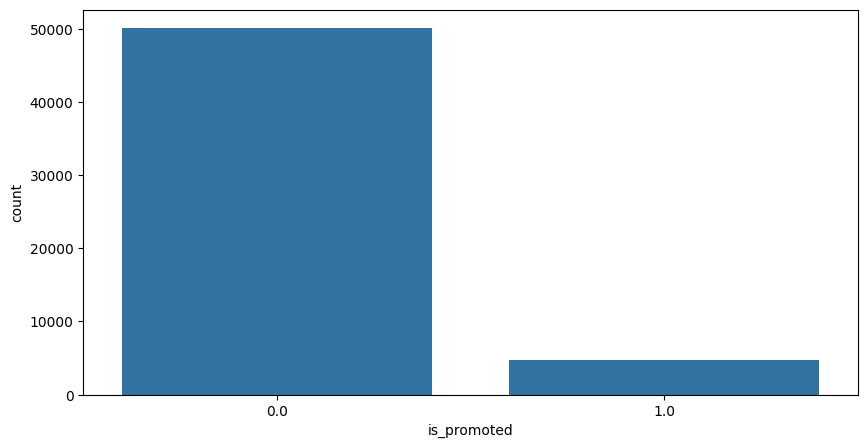

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='is_promoted',data=df)
plt.show()

we will use smote for balancing as an alternative of ROS

In [10]:
from imblearn.over_sampling import SMOTE
from collections import Counter
X=df.drop('is_promoted',axis=1)
y=df['is_promoted']
smote=SMOTE(random_state=42)
X_resampled,y_resampled=smote.fit_resample(X,y)
x_resampled=pd.DataFrame(X_resampled,columns=X.columns)
y_resampled=pd.DataFrame(y_resampled,columns=['is_promoted'])
y_resampled['is_promoted'].value_counts()

,count
is_promoted,
0.0,50140
1.0,50140


corrolation matrix

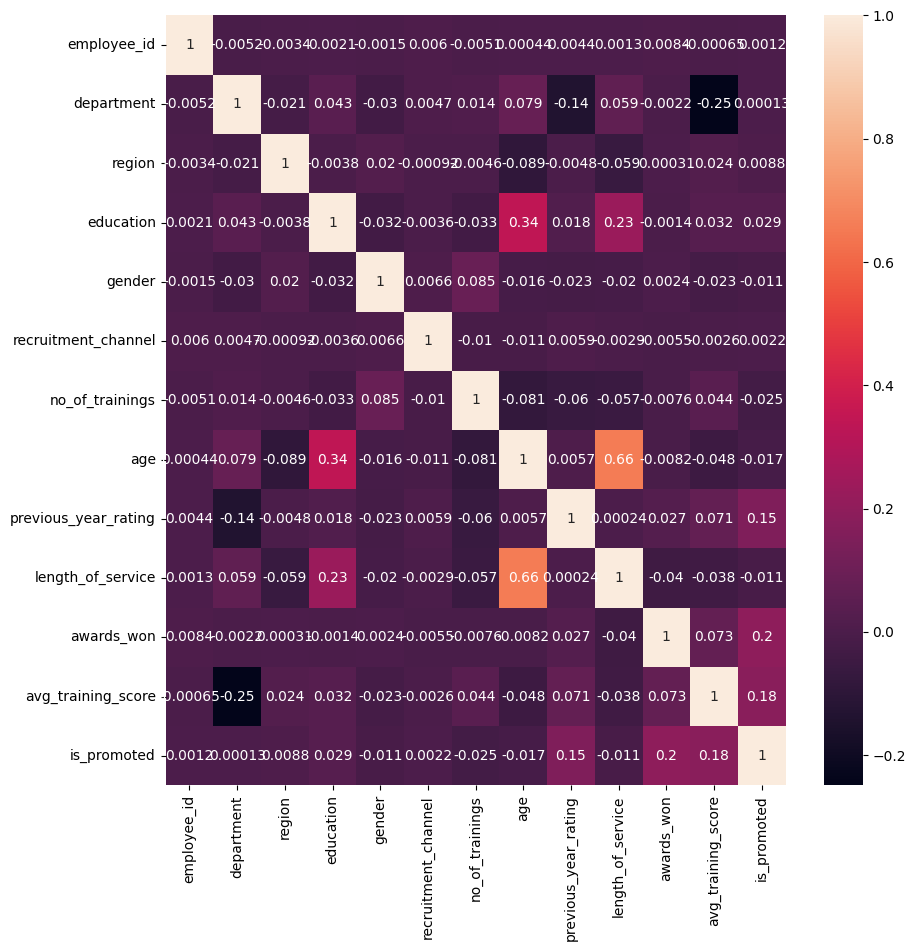

In [ ]:
from seaborn import heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


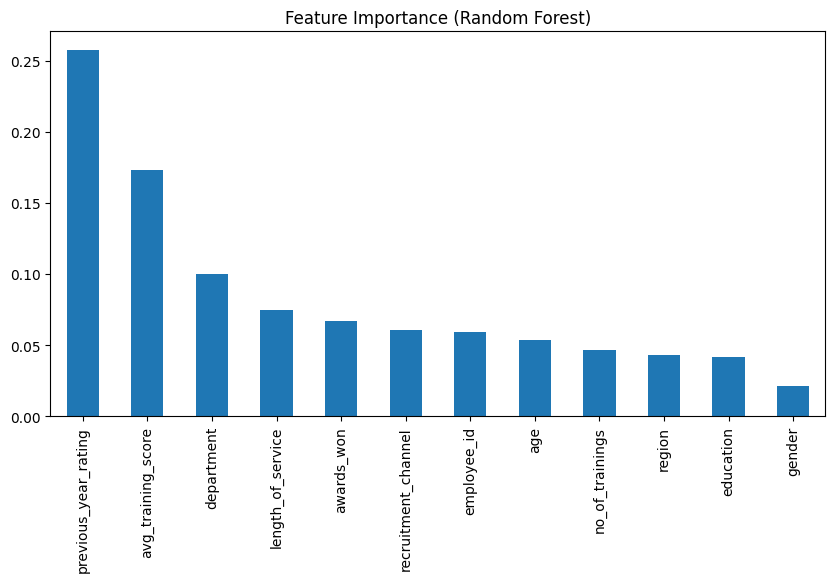

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_resampled, y_resampled)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

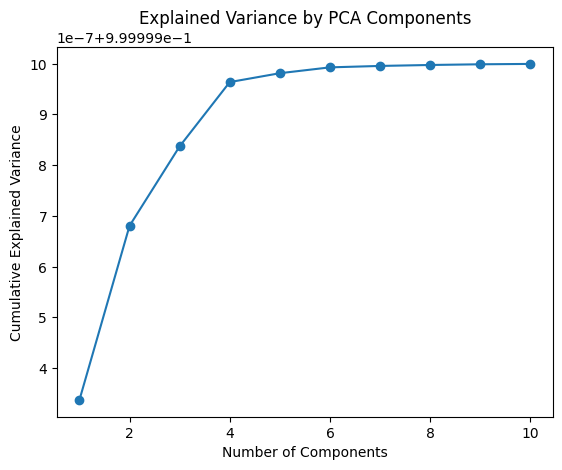

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=10)  # Select number of components
X_pca = pca.fit_transform(X)

# Plot explained variance
plt.plot(range(1, 11), pca.explained_variance_ratio_.cumsum(), marker="o")
plt.title("Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

we can choose the 6 most important features and splitting the data to train and test

In [ ]:
X_resampled.drop(['employee_id','age','region','education','gender','no_of_trainings'],axis=1,inplace=True)

In [ ]:
X_resampled.head()

,department,recruitment_channel,previous_year_rating,length_of_service,awards_won,avg_training_score
0,7,2,5.0,8.0,0.0,49.0
1,4,0,5.0,4.0,0.0,60.0
2,7,2,3.0,7.0,0.0,50.0
3,7,0,1.0,10.0,0.0,50.0
4,8,0,3.0,2.0,0.0,73.0


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

we will try simple models at first

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
print(accuracy_score(y_test,y_pred_lr))
print(classification_report(y_test,y_pred_lr))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.6934084563222975
              precision    recall  f1-score   support

         0.0       0.70      0.70      0.70     10197
         1.0       0.69      0.69      0.69      9859

    accuracy                           0.69     20056
   macro avg       0.69      0.69      0.69     20056
weighted avg       0.69      0.69      0.69     20056



In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
print(accuracy_score(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))

0.9523833266852813
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     10197
         1.0       0.98      0.92      0.95      9859

    accuracy                           0.95     20056
   macro avg       0.95      0.95      0.95     20056
weighted avg       0.95      0.95      0.95     20056



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.951934583167132
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     10197
         1.0       0.98      0.92      0.95      9859

    accuracy                           0.95     20056
   macro avg       0.95      0.95      0.95     20056
weighted avg       0.95      0.95      0.95     20056



In [ ]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)
print(accuracy_score(y_test,y_pred_svm))
print(classification_report(y_test,y_pred_svm))


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.7112086158755485
              precision    recall  f1-score   support

         0.0       0.75      0.65      0.70     10197
         1.0       0.68      0.78      0.73      9859

    accuracy                           0.71     20056
   macro avg       0.72      0.71      0.71     20056
weighted avg       0.72      0.71      0.71     20056



stacking model using lr as a meta model and the rest as stacking models

In [ ]:
from sklearn.ensemble import StackingClassifier
stacking_model = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('dt', DecisionTreeClassifier()),
        ('rf', RandomForestClassifier()),
        ('svm', SVC())
    ],
    final_estimator=LogisticRegression()
)
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)
print(accuracy_score(y_test, y_pred_stacking))
print(classification_report(y_test, y_pred_stacking))


/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear

0.9501894694854408
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95     10197
         1.0       0.97      0.93      0.95      9859

    accuracy                           0.95     20056
   macro avg       0.95      0.95      0.95     20056
weighted avg       0.95      0.95      0.95     20056

